<a href="https://colab.research.google.com/github/NandanaRN/Natural_Language_Processing/blob/main/PROJECT_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Project 11: Job Resume Screening

## Problem Statement

An HR department receives hundreds of resumes for different job openings. Manually reviewing each resume to identify suitable candidates requires significant time and effort.

This project uses Natural Language Processing (NLP) techniques to automatically process resume text, extract important skills and qualifications, match candidates with suitable job roles, and generate a shortlist of the most relevant candidates.

## Objectives

1. Create a resume dataset.
2. Preprocess resume text.
3. Extract important skills and qualifications.
4. Match resumes with suitable job roles.
5. Rank candidates based on job requirements.
6. Generate a candidate shortlist.

## 1. Import Required Libraries

The following libraries are used for data manipulation, text preprocessing, NLP, similarity calculation, and visualization.

In [53]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Creating the Resume Dataset

Since a resume dataset is not provided, a synthetic resume dataset is created for this project.

Each resume contains:

- Candidate name
- Education
- Skills
- Experience
- Resume text
- Target job role

The dataset contains resumes representing different technical and creative roles.

In [54]:
resumes = [

("Aarav Sharma",
 "MCA",
 "Python, Machine Learning, Deep Learning, TensorFlow, NLP, Generative AI, Transformers",
 "2 years",
 "MCA graduate with experience in Python, machine learning, deep learning, NLP and generative AI. Worked with TensorFlow, transformers and natural language processing projects.",
 "Generative AI Engineer"),

("Meera Nair",
 "MSc Data Science",
 "Python, Pandas, NumPy, SQL, Machine Learning, Statistics, Power BI",
 "2 years",
 "Data science professional experienced in Python, SQL, statistics, machine learning, Pandas and Power BI. Worked on predictive analytics and business intelligence projects.",
 "Data Scientist"),

("Rohan Kumar",
 "BTech Computer Science",
 "Python, Java, Machine Learning, Scikit-learn, TensorFlow, Docker",
 "3 years",
 "Machine learning engineer with strong Python and Java skills. Experienced in developing machine learning models using Scikit-learn and TensorFlow and deploying applications using Docker.",
 "Machine Learning Engineer"),

("Ananya Menon",
 "BCA",
 "HTML, CSS, JavaScript, React, Node.js, MongoDB, Git",
 "2 years",
 "Frontend and web developer experienced in HTML, CSS, JavaScript and React. Has worked with Node.js, MongoDB and Git to develop responsive web applications.",
 "Web Developer"),

("Vivek Raj",
 "MCA",
 "Python, SQL, Excel, Power BI, Tableau, Data Visualization",
 "1 year",
 "MCA graduate with experience in data analysis using Python, SQL and Excel. Skilled in Power BI, Tableau and data visualization for business reporting.",
 "Data Analyst"),

("Diya Thomas",
 "MDes",
 "UI UX Design, Figma, User Research, Prototyping, Wireframing, AI Products",
 "2 years",
 "AI product designer experienced in UI UX design, Figma, prototyping and user research. Interested in designing intuitive interfaces for AI-powered products.",
 "AI Product Designer"),

("Kiran Patel",
 "BTech Artificial Intelligence",
 "Python, NLP, LLM, RAG, LangChain, Transformers, Prompt Engineering",
 "2 years",
 "AI engineer experienced in Python, NLP, large language models, RAG, LangChain and transformers. Developed generative AI applications using prompt engineering.",
 "Generative AI Engineer"),

("Sneha Iyer",
 "MSc Computer Science",
 "Python, Machine Learning, NLP, Deep Learning, PyTorch, Hugging Face",
 "3 years",
 "Computer science postgraduate with experience in machine learning, NLP and deep learning. Skilled in PyTorch and Hugging Face and worked on text classification applications.",
 "Machine Learning Engineer"),

("Rahul Das",
 "BSc Statistics",
 "Python, SQL, Statistics, Machine Learning, Pandas, NumPy",
 "2 years",
 "Statistics graduate with strong analytical skills. Experienced in Python, SQL, statistics, Pandas and NumPy. Worked on machine learning and predictive analytics projects.",
 "Data Scientist"),

("Ishita Rao",
 "BTech Information Science",
 "HTML, CSS, JavaScript, React, Angular, REST API, Git",
 "3 years",
 "Web developer with experience in JavaScript, React and Angular. Skilled in building responsive web applications and integrating REST APIs using modern development tools.",
 "Web Developer"),

("Arjun Menon",
 "MBA",
 "Excel, SQL, Power BI, Tableau, Business Analytics, Data Visualization",
 "2 years",
 "Business analytics professional experienced in SQL, Excel, Power BI and Tableau. Skilled in creating dashboards and analyzing business data.",
 "Data Analyst"),

("Nandini Joseph",
 "BDes",
 "Figma, UI UX, Wireframing, Prototyping, User Research, Product Design",
 "2 years",
 "Product designer with experience in Figma, UI UX design, wireframing, prototyping and user research. Designed digital products with a focus on usability and user experience.",
 "AI Product Designer"),

("Aditya Singh",
 "MTech Artificial Intelligence",
 "Python, Deep Learning, NLP, Computer Vision, PyTorch, Transformers",
 "4 years",
 "Artificial intelligence specialist with experience in Python, deep learning, NLP and computer vision. Skilled in PyTorch and transformer-based models.",
 "Generative AI Engineer"),

("Priya Menon",
 "MCA",
 "Python, SQL, Machine Learning, Pandas, Scikit-learn, Data Analysis",
 "2 years",
 "MCA graduate with skills in Python, SQL, machine learning, Pandas and Scikit-learn. Experienced in data analysis and predictive modelling.",
 "Data Scientist"),

("Vishal Kumar",
 "BTech Computer Science",
 "JavaScript, React, HTML, CSS, Node.js, Express, MongoDB",
 "2 years",
 "Full stack developer experienced in JavaScript, React, Node.js, Express and MongoDB. Developed and maintained web applications.",
 "Web Developer")
]

df = pd.DataFrame(
    resumes,
    columns=[
        "Candidate",
        "Education",
        "Skills",
        "Experience",
        "Resume_Text",
        "Target_Role"
    ]
)

print("Resume dataset created successfully!")
print("Number of resumes:", len(df))

df.head()

Resume dataset created successfully!
Number of resumes: 15


,Candidate,Education,Skills,Experience,Resume_Text,Target_Role
0,Aarav Sharma,MCA,"Python, Machine Learning, Deep Learning, Tenso...",2 years,"MCA graduate with experience in Python, machin...",Generative AI Engineer
1,Meera Nair,MSc Data Science,"Python, Pandas, NumPy, SQL, Machine Learning, ...",2 years,Data science professional experienced in Pytho...,Data Scientist
2,Rohan Kumar,BTech Computer Science,"Python, Java, Machine Learning, Scikit-learn, ...",3 years,Machine learning engineer with strong Python a...,Machine Learning Engineer
3,Ananya Menon,BCA,"HTML, CSS, JavaScript, React, Node.js, MongoDB...",2 years,Frontend and web developer experienced in HTML...,Web Developer
4,Vivek Raj,MCA,"Python, SQL, Excel, Power BI, Tableau, Data Vi...",1 year,MCA graduate with experience in data analysis ...,Data Analyst


## 3. Dataset Exploration

The dataset is examined to understand its structure, number of resumes, qualifications, and job role distribution.

In [55]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nJob Role Distribution:")
print(df["Target_Role"].value_counts())

Dataset Shape: (15, 6)

Columns:
['Candidate', 'Education', 'Skills', 'Experience', 'Resume_Text', 'Target_Role']

Missing Values:
Candidate      0
Education      0
Skills         0
Experience     0
Resume_Text    0
Target_Role    0
dtype: int64

Job Role Distribution:
Target_Role
Generative AI Engineer       3
Data Scientist               3
Web Developer                3
Machine Learning Engineer    2
Data Analyst                 2
AI Product Designer          2
Name: count, dtype: int64


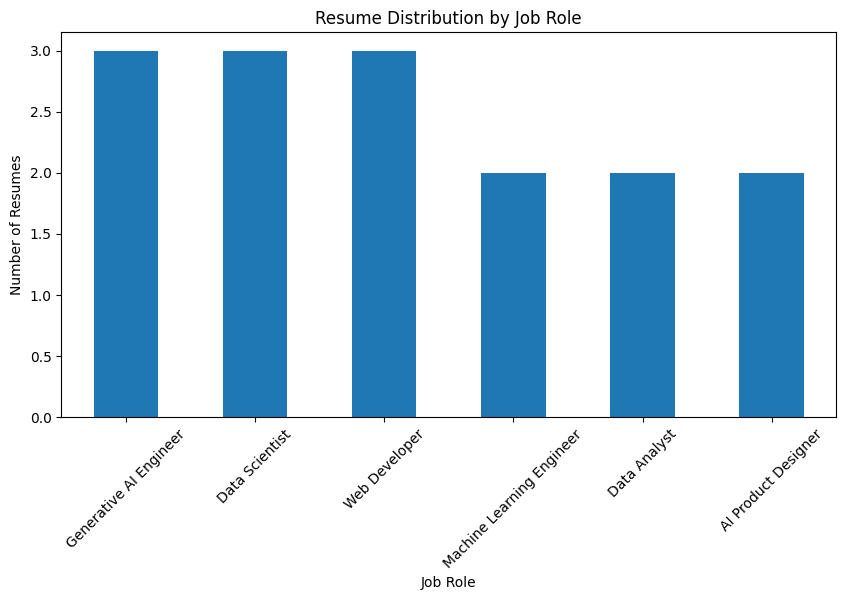

In [56]:
plt.figure(figsize=(10, 5))

df["Target_Role"].value_counts().plot(kind="bar")

plt.title("Resume Distribution by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

## 4. Resume Text Preprocessing

Resume text contains unnecessary punctuation, uppercase characters, and common words.

The following preprocessing techniques are applied:

1. Convert text to lowercase.
2. Remove punctuation.
3. Remove numbers.
4. Remove stopwords.
5. Apply lemmatization.

This produces cleaner text for NLP processing.

In [57]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\d+", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Cleaned_Resume"] = df["Resume_Text"].apply(preprocess_text)

df[["Resume_Text", "Cleaned_Resume"]].head()

,Resume_Text,Cleaned_Resume
0,"MCA graduate with experience in Python, machin...",mca graduate experience python machine learnin...
1,Data science professional experienced in Pytho...,data science professional experienced python s...
2,Machine learning engineer with strong Python a...,machine learning engineer strong python java s...
3,Frontend and web developer experienced in HTML...,frontend web developer experienced html cs jav...
4,MCA graduate with experience in data analysis ...,mca graduate experience data analysis using py...


## 5. Skill Extraction

A predefined skill dictionary is created to identify important technical and professional skills from resumes.

The extracted skills can help HR teams quickly understand the capabilities of each candidate.

In [58]:
skills_list = [
    "python",
    "java",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "nlp",
    "generative ai",
    "transformers",
    "llm",
    "rag",
    "langchain",
    "prompt engineering",
    "scikit-learn",
    "pandas",
    "numpy",
    "sql",
    "power bi",
    "tableau",
    "excel",
    "data visualization",
    "html",
    "css",
    "javascript",
    "react",
    "angular",
    "node.js",
    "mongodb",
    "git",
    "figma",
    "ui ux",
    "user research",
    "prototyping",
    "wireframing",
    "product design"
]

def extract_skills(text):
    text = text.lower()

    found_skills = []

    for skill in skills_list:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills

df["Extracted_Skills"] = df["Resume_Text"].apply(extract_skills)

df[["Candidate", "Extracted_Skills"]]

,Candidate,Extracted_Skills
0,Aarav Sharma,"[python, machine learning, deep learning, tens..."
1,Meera Nair,"[python, machine learning, pandas, sql, power bi]"
2,Rohan Kumar,"[python, java, machine learning, tensorflow, s..."
3,Ananya Menon,"[java, html, css, javascript, react, node.js, ..."
4,Vivek Raj,"[python, sql, power bi, tableau, excel, data v..."
5,Diya Thomas,"[figma, ui ux, user research, prototyping, pro..."
6,Kiran Patel,"[python, nlp, generative ai, transformers, rag..."
7,Sneha Iyer,"[machine learning, deep learning, pytorch, nlp]"
8,Rahul Das,"[python, machine learning, pandas, numpy, sql]"
9,Ishita Rao,"[java, javascript, react, angular]"


## 6. Skill Frequency Analysis

The frequency of skills across all resumes is analyzed to identify the most common skills among candidates.

In [59]:
from collections import Counter

all_skills = []

for skills in df["Extracted_Skills"]:
    all_skills.extend(skills)

skill_frequency = Counter(all_skills)

skill_df = pd.DataFrame(
    skill_frequency.most_common(),
    columns=["Skill", "Frequency"]
)

skill_df.head(15)

,Skill,Frequency
0,python,8
1,machine learning,6
2,sql,5
3,nlp,4
4,java,4
5,deep learning,3
6,pandas,3
7,power bi,3
8,javascript,3
9,react,3


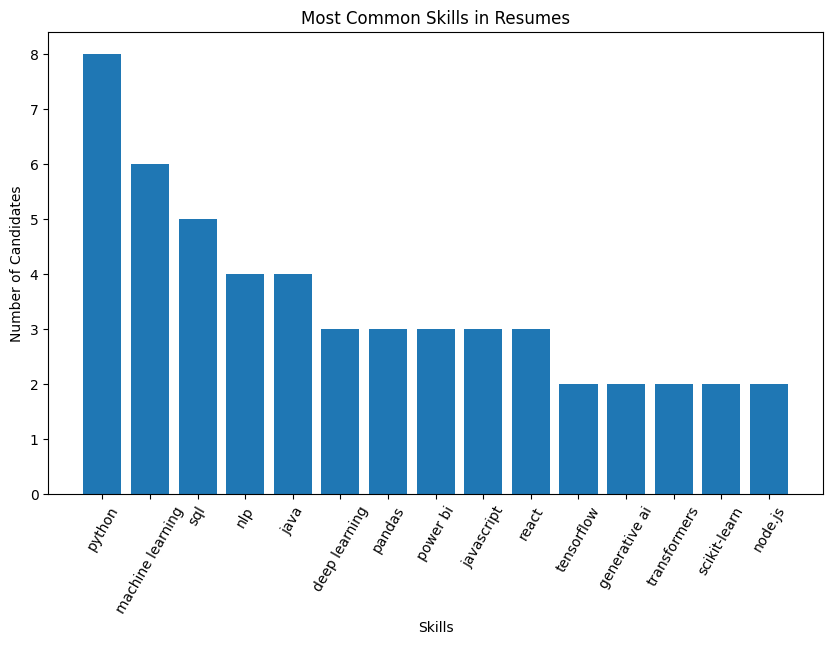

In [60]:
top_skills = skill_df.head(15)

plt.figure(figsize=(10, 6))

plt.bar(
    top_skills["Skill"],
    top_skills["Frequency"]
)

plt.title("Most Common Skills in Resumes")
plt.xlabel("Skills")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=60)

plt.show()

## 7. Defining Job Requirements

Different job roles require different skills.

A job requirement dictionary is created containing the important skills required for each role.

In [61]:
job_requirements = {

    "Generative AI Engineer":
    """
    Python NLP Generative AI Transformers LLM RAG
    LangChain Prompt Engineering Deep Learning
    """,

    "Data Scientist":
    """
    Python Machine Learning Statistics SQL
    Pandas NumPy Power BI Data Analysis
    """,

    "Machine Learning Engineer":
    """
    Python Machine Learning Deep Learning
    TensorFlow PyTorch Scikit-learn NLP
    Transformers Docker
    """,

    "Web Developer":
    """
    HTML CSS JavaScript React Node.js
    MongoDB Git REST API
    """,

    "Data Analyst":
    """
    Python SQL Excel Power BI Tableau
    Data Visualization Business Analytics
    """,

    "AI Product Designer":
    """
    Figma UI UX User Research
    Prototyping Wireframing Product Design
    AI Products
    """
}

job_df = pd.DataFrame(
    job_requirements.items(),
    columns=["Job_Role", "Requirements"]
)

job_df

,Job_Role,Requirements
0,Generative AI Engineer,\n Python NLP Generative AI Transformers LL...
1,Data Scientist,\n Python Machine Learning Statistics SQL\n...
2,Machine Learning Engineer,\n Python Machine Learning Deep Learning\n ...
3,Web Developer,\n HTML CSS JavaScript React Node.js\n M...
4,Data Analyst,\n Python SQL Excel Power BI Tableau\n D...
5,AI Product Designer,\n Figma UI UX User Research\n Prototypi...


## 8. Resume-Job Matching Using TF-IDF

TF-IDF is used to convert resume text and job requirements into numerical vectors.

Cosine similarity is then calculated between each resume and each job description.

A higher cosine similarity score indicates a stronger match between the candidate's resume and the job role.

In [62]:
documents = list(df["Cleaned_Resume"]) + list(job_requirements.values())

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

resume_vectors = tfidf_matrix[:len(df)]
job_vectors = tfidf_matrix[len(df):]

similarity_matrix = cosine_similarity(
    resume_vectors,
    job_vectors
)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (15, 6)


## 9. Finding the Best Job Role for Each Candidate

For each resume, the job role with the highest similarity score is selected as the most suitable role.

In [63]:
job_roles = list(job_requirements.keys())

best_roles = []
best_scores = []

for scores in similarity_matrix:

    best_index = np.argmax(scores)

    best_roles.append(job_roles[best_index])

    best_scores.append(scores[best_index])

df["Recommended_Role"] = best_roles
df["Match_Score"] = best_scores

df[[
    "Candidate",
    "Recommended_Role",
    "Match_Score"
]]

,Candidate,Recommended_Role,Match_Score
0,Aarav Sharma,Machine Learning Engineer,0.348410
1,Meera Nair,Data Analyst,0.432815
2,Rohan Kumar,Machine Learning Engineer,0.330676
3,Ananya Menon,Web Developer,0.329869
4,Vivek Raj,Data Analyst,0.692252
5,Diya Thomas,AI Product Designer,0.620914
6,Kiran Patel,Generative AI Engineer,0.559450
7,Sneha Iyer,Machine Learning Engineer,0.313544
8,Rahul Das,Data Scientist,0.234433
9,Ishita Rao,Web Developer,0.170333


In [64]:
df["Match_Percentage"] = (
    df["Match_Score"] * 100
).round(2)

df[[
    "Candidate",
    "Recommended_Role",
    "Match_Percentage"
]].sort_values(
    "Match_Percentage",
    ascending=False
)

,Candidate,Recommended_Role,Match_Percentage
4,Vivek Raj,Data Analyst,69.23
11,Nandini Joseph,AI Product Designer,65.76
10,Arjun Menon,Data Analyst,63.90
5,Diya Thomas,AI Product Designer,62.09
6,Kiran Patel,Generative AI Engineer,55.95
1,Meera Nair,Data Analyst,43.28
0,Aarav Sharma,Machine Learning Engineer,34.84
2,Rohan Kumar,Machine Learning Engineer,33.07
3,Ananya Menon,Web Developer,32.99
13,Priya Menon,Data Scientist,32.92


## 10. Candidate Shortlisting

Candidates with a match score above a predefined threshold are shortlisted.

For this project, candidates with a similarity score of 20% or higher are considered suitable for further screening.

In [65]:
threshold = 20

shortlisted = df[
    df["Match_Percentage"] >= threshold
].copy()

shortlisted = shortlisted.sort_values(
    "Match_Percentage",
    ascending=False
)

print("Number of shortlisted candidates:",
      len(shortlisted))

shortlisted[[
    "Candidate",
    "Education",
    "Experience",
    "Recommended_Role",
    "Match_Percentage",
    "Extracted_Skills"
]]

Number of shortlisted candidates: 13


,Candidate,Education,Experience,Recommended_Role,Match_Percentage,Extracted_Skills
4,Vivek Raj,MCA,1 year,Data Analyst,69.23,"[python, sql, power bi, tableau, excel, data v..."
11,Nandini Joseph,BDes,2 years,AI Product Designer,65.76,"[git, figma, ui ux, user research, prototyping..."
10,Arjun Menon,MBA,2 years,Data Analyst,63.90,"[sql, power bi, tableau, excel]"
5,Diya Thomas,MDes,2 years,AI Product Designer,62.09,"[figma, ui ux, user research, prototyping, pro..."
6,Kiran Patel,BTech Artificial Intelligence,2 years,Generative AI Engineer,55.95,"[python, nlp, generative ai, transformers, rag..."
1,Meera Nair,MSc Data Science,2 years,Data Analyst,43.28,"[python, machine learning, pandas, sql, power bi]"
0,Aarav Sharma,MCA,2 years,Machine Learning Engineer,34.84,"[python, machine learning, deep learning, tens..."
2,Rohan Kumar,BTech Computer Science,3 years,Machine Learning Engineer,33.07,"[python, java, machine learning, tensorflow, s..."
3,Ananya Menon,BCA,2 years,Web Developer,32.99,"[java, html, css, javascript, react, node.js, ..."
13,Priya Menon,MCA,2 years,Data Scientist,32.92,"[python, machine learning, scikit-learn, panda..."


## 11. Candidate Ranking

The shortlisted candidates are ranked according to their resume-job similarity score.

Candidates with higher scores have stronger textual similarity with the requirements of the recommended job role.

In [66]:
ranking = shortlisted[[
    "Candidate",
    "Recommended_Role",
    "Experience",
    "Match_Percentage"
]].copy()

ranking.insert(
    0,
    "Rank",
    range(1, len(ranking) + 1)
)

ranking

,Rank,Candidate,Recommended_Role,Experience,Match_Percentage
4,1,Vivek Raj,Data Analyst,1 year,69.23
11,2,Nandini Joseph,AI Product Designer,2 years,65.76
10,3,Arjun Menon,Data Analyst,2 years,63.90
5,4,Diya Thomas,AI Product Designer,2 years,62.09
6,5,Kiran Patel,Generative AI Engineer,2 years,55.95
1,6,Meera Nair,Data Analyst,2 years,43.28
0,7,Aarav Sharma,Machine Learning Engineer,2 years,34.84
2,8,Rohan Kumar,Machine Learning Engineer,3 years,33.07
3,9,Ananya Menon,Web Developer,2 years,32.99
13,10,Priya Menon,Data Scientist,2 years,32.92


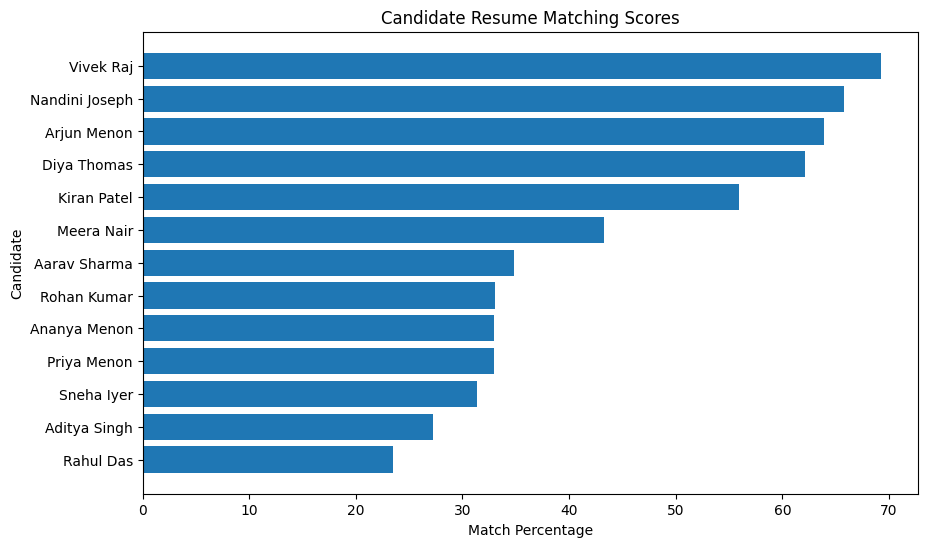

In [67]:
plt.figure(figsize=(10, 6))

plt.barh(
    ranking["Candidate"],
    ranking["Match_Percentage"]
)

plt.xlabel("Match Percentage")
plt.ylabel("Candidate")
plt.title("Candidate Resume Matching Scores")

plt.gca().invert_yaxis()

plt.show()

## 12. Testing with a New Resume

The system can also screen a new resume that was not included in the original dataset.

The new resume is compared with all available job roles and the most suitable role is recommended.

In [68]:
new_resume = """
MCA graduate with strong experience in Python, natural language processing,
large language models, generative AI, transformers, RAG and prompt engineering.
Worked on AI applications using LangChain and machine learning.
"""

cleaned_new_resume = preprocess_text(new_resume)

new_vector = vectorizer.transform(
    [cleaned_new_resume]
)

new_similarity = cosine_similarity(
    new_vector,
    job_vectors
)[0]

new_results = pd.DataFrame({
    "Job Role": job_roles,
    "Match Score": new_similarity * 100
})

new_results = new_results.sort_values(
    "Match Score",
    ascending=False
)

new_results

,Job Role,Match Score
0,Generative AI Engineer,45.121326
2,Machine Learning Engineer,8.982545
5,AI Product Designer,8.084712
1,Data Scientist,7.512466
4,Data Analyst,2.157249
3,Web Developer,0.000000


In [69]:
best_new_role = new_results.iloc[0]["Job Role"]
best_new_score = new_results.iloc[0]["Match Score"]

print("Recommended Job Role:", best_new_role)
print("Match Score:", round(best_new_score, 2), "%")

Recommended Job Role: Generative AI Engineer
Match Score: 45.12 %


## 13. Analytical Report

The following report summarizes the resume screening results, most common skills, recommended job roles, and shortlisted candidates.

In [70]:
print("=" * 65)
print("             JOB RESUME SCREENING REPORT")
print("=" * 65)

print("\nTotal Resumes Analyzed:", len(df))

print("\nNumber of Job Roles:", len(job_requirements))

print("\nMost Common Skills:")

for skill, count in skill_frequency.most_common(10):
    print(f"- {skill}: {count} candidates")

print("\nRecommended Role Distribution:")
print(df["Recommended_Role"].value_counts())

print("\nShortlisted Candidates:")
print(len(shortlisted))

print("\nCandidate Ranking:")
print(
    ranking[
        [
            "Rank",
            "Candidate",
            "Recommended_Role",
            "Match_Percentage"
        ]
    ].to_string(index=False)
)

print("\nHighest Ranked Candidate:")

top_candidate = ranking.iloc[0]

print("Candidate:", top_candidate["Candidate"])
print("Role:", top_candidate["Recommended_Role"])
print("Match:", top_candidate["Match_Percentage"], "%")

print("\nConclusion:")
print(
    "The NLP-based resume screening system successfully "
    "preprocesses resumes, extracts relevant skills, "
    "matches candidates with suitable job roles, and "
    "generates a ranked shortlist using TF-IDF and "
    "cosine similarity."
)

print("=" * 65)

             JOB RESUME SCREENING REPORT

Total Resumes Analyzed: 15

Number of Job Roles: 6

Most Common Skills:
- python: 8 candidates
- machine learning: 6 candidates
- sql: 5 candidates
- nlp: 4 candidates
- java: 4 candidates
- deep learning: 3 candidates
- pandas: 3 candidates
- power bi: 3 candidates
- javascript: 3 candidates
- react: 3 candidates

Recommended Role Distribution:
Recommended_Role
Machine Learning Engineer    4
Data Analyst                 3
Web Developer                3
AI Product Designer          2
Data Scientist               2
Generative AI Engineer       1
Name: count, dtype: int64

Shortlisted Candidates:
13

Candidate Ranking:
 Rank      Candidate          Recommended_Role  Match_Percentage
    1      Vivek Raj              Data Analyst             69.23
    2 Nandini Joseph       AI Product Designer             65.76
    3    Arjun Menon              Data Analyst             63.90
    4    Diya Thomas       AI Product Designer             62.09
    5   

# 14. Conclusion

The Job Resume Screening system demonstrates how Natural Language Processing can automate the initial stage of recruitment.

A synthetic resume dataset was created containing candidates from different technical and creative backgrounds. Resume text was cleaned using NLP preprocessing techniques such as lowercasing, punctuation removal, stopword removal, and lemmatization.

Important skills were extracted from resumes using a predefined skill dictionary. TF-IDF was then used to represent resumes and job requirements numerically. Cosine similarity was used to calculate how closely each resume matched the requirements of different job roles.

The system successfully recommends suitable job roles and generates a ranked candidate shortlist.

## Future Scope

The system can be improved by:

- Using a larger real-world resume dataset.
- Using BERT or other transformer-based models.
- Extracting skills automatically using Named Entity Recognition.
- Extracting education and work experience automatically.
- Adding semantic similarity instead of only keyword similarity.
- Adding a web-based HR dashboard.
- Adding fairness and bias detection to avoid discriminatory hiring decisions.